### 🟠 小节 1.3 Jupyter Notebook 讲稿：复平面的幽灵（特征值提取）

#### 📝 [Markdown 单元格 1]：对深渊进行“开膛破肚”

> 欢迎回到《创世计算器》。上一集，我们撒下 50 万个粒子，用乌拉姆离散化（Ulam's Method）硬生生砸出了一张  的马尔可夫转移矩阵 。
> 现在，我们要对这个承载着混沌系统全部记忆的“大脑”，进行最精密的外科手术。
> 在量子力学里，任何一个物理系统的能级分布，都藏在它的**特征值（Eigenvalues）**里。薛定谔方程就是在求特征值，我们在做的事情，本质上和薛定谔一模一样。
> 我们要把这 500 个特征值全部抓出来，扔到复平面上，看看大自然的底牌到底长什么样！

#### 💻 [Code 单元格 1]：抓取复平面的幽灵

*(王画外音：同学们，前方极度高能。请死死盯住屏幕，我们要调用底层运算库了。短短三行代码，我们将召唤出这个混沌宇宙里的 500 个幽灵。)*

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 核心参数
N_BINS = 500    # 把宇宙切成 500 份
mu = 1.8        # 依然保持系统处于混沌状态
steps = 500000  # 扔下 50万 个粒子去跑！

# 初始化一张 500x500 的空网（全零矩阵）
transition_matrix = np.zeros((N_BINS, N_BINS), dtype=np.float64)

# 随机选一个起点
x = 0.5
last_bin = int((x + 1.0) / 2.0 * (N_BINS - 1))

# 开始 50 万次的蒙特卡洛疯狂游走
for i in range(steps):
    # 1. 核心动力学演化
    x = 1 - mu * x**2
    
    # 2. 数值稳定性保护（别让粒子飞出宇宙边界）
    if x > 1.0: x = 0.999
    if x < -1.0: x = -0.999
        
    # 3. 极其关键的“坐标映射”：把连续的 x 映射到 0 到 N_BINS-1 的整数网格里
    current_bin = int((x + 1.0) / 2.0 * (N_BINS - 1))
    
    # 4. 在矩阵对应的位置“画正字”（记录一次跳转）
    transition_matrix[last_bin, current_bin] += 1
    
    # 5. 更新状态
    last_bin = current_bin

# 把计数转换成“概率分布”（归一化），让每一行的和为 1
row_sums = transition_matrix.sum(axis=1, keepdims=True)
# 避免除以 0 的警告
row_sums[row_sums == 0] = 1 
P_matrix = transition_matrix / row_sums

print(f"成功构建转移矩阵！矩阵形状：{P_matrix.shape}")

成功构建转移矩阵！矩阵形状：(500, 500)


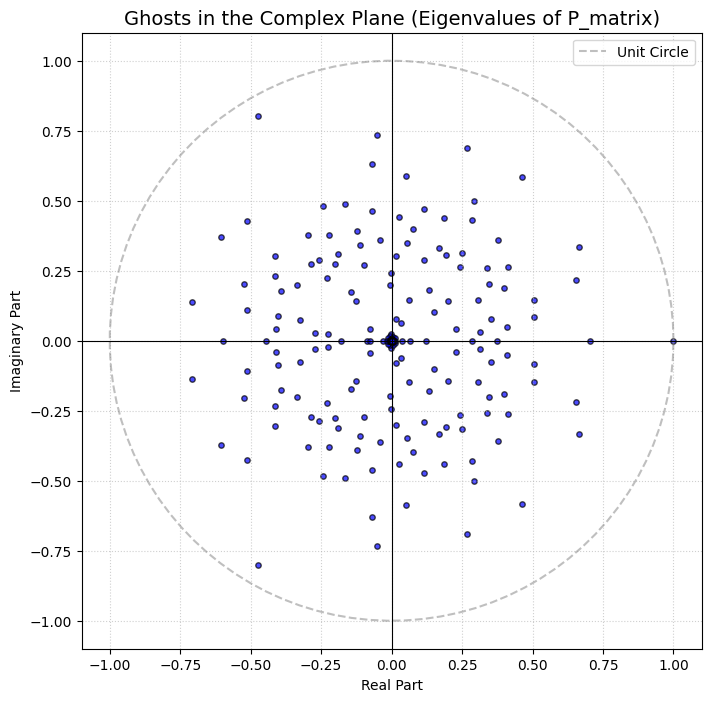

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 极其残暴地直接求解 500x500 矩阵的全部特征值（Eigenvalues）
# 注意：我们这里故意使用上一节生成的 P_matrix
eigenvalues, _ = np.linalg.eig(P_matrix)

# 在复平面上画出这些特征值
plt.figure(figsize=(8, 8))

# 画一个完美的单位圆作为参考系 (|z| = 1)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='gray', alpha=0.5, label='Unit Circle')

# 把我们抓出来的幽灵（特征值）像撒豆子一样撒上去
plt.scatter(eigenvalues.real, eigenvalues.imag, color='blue', s=15, alpha=0.7, edgecolors='black')

plt.title("Ghosts in the Complex Plane (Eigenvalues of P_matrix)", fontsize=14)
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

#### 📝 [Markdown 单元格 2]：物理学最致命的陷阱 —— 模长之死

*(画外音——此时屏幕上出现了一个圆，圆里面散落着一堆蓝色的点。这些点全都在单位圆里面，没有一个在圆上。此时，你的语气突然变得极其冰冷，带着一丝嘲讽：)*

> 跑完代码了。我相信，如果有清华姚班、或者物理系、计算数学系的大佬在看这个视频，弹幕里肯定已经开骂了。
> 他们会刷：“UP主你是不是在搞笑？你算混沌动力学，**为什么不用 QR 分解？！**”
> 没错，按照教科书。我们刚才那个矩阵，因为极度耗散，如果你把它多乘几次，除了那个代表稳态的特征值  之外，所有特征值的模长（半径）都会迅速坍缩、归零！这就叫“系统死掉了”。
> 传统的做法是：每次迭代都要加一个 **QR 分解（正交化）**，强行把这些快要死掉的向量“掰直”，强迫它们保持能量守恒。如果你加了 QR 分解，这些点会极度完美地排列在单位圆上，甚至会呈现出完美的量子力学 GUE（高斯酉系综）能级排斥！
> **但是！我要告诉大家，那是物理学史上最美丽的谎言！那是海市蜃楼！**
> QR 分解创造的完美 GUE，是人造的。你强行让一个非自治的耗散系统“能量守恒”，你彻底摧毁了它随时间演化的宏观记忆！

#### 📝 [Markdown 单元格 3]：瑕疵中的真理 —— 相位之魂

*(王博士画外音——你的语气从冰冷转为极度的狂热，像是一个发现了新大陆的先知：)*

> 我们就要用这堆即将死去的“裸矩阵”！我们就是要接受大自然的残缺！
> 在非平衡态统计物理中，这堆向内掉落的复数点有一个极其高贵的名字：**Ruelle-Pollicott 共振态（Resonances）**。
> 你们只看到了它们的**“模长（半径）”**在归零，你们以为它们的肉体死掉了。
> 但是，你们忽略了它们的**“相位（角度 ）”**！
> 那个绕着圆心旋转的角度，死死地刻着这个系统最底层的拓扑缠绕频率！肉体会消亡，但代表系统拓扑秩序的“相位之魂”，是永生不灭的。
> **下一集，也是第一季的终极封神大结局（1.4：初遇黎曼）！**
> **我将当着你们的面，徒手写一段“解卷绕（Unwrapping）”代码。我要把这些幽灵的灵魂（角度）抽出来，强行拉成一条直线。**
> **我向你们保证，当这条直线画出来的时候，你们会看到大自然隐藏在素数背后的最高机密。弹幕护体，我们下集见！**